In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Encoding & Scaling
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Modeling
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Imbalanced data handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 2. 📂 Load Dataset

In [2]:
# Load data — adjust path if needed
df = pd.read_csv('data_1.csv')

print(f'📊 Shape: {df.shape}')
print(f'📋 Columns ({len(df.columns)}):')
print(df.columns.tolist())
df.head(3)

📊 Shape: (1000000, 35)
📋 Columns (35):
['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory ']


,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,ltime,seq,dur,mean,stddev,smac,dmac,sum,min,max,soui,doui,sco,dco,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,1,1526344121.1881,e,arp,192.168.100.1,NaN,192.168.100.3,NaN,4,240,CON,1526345317.1847,9,1195.9966,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,2,2,120,120,0.0025,0.0008,0.0008,0,Normal,Normal
1,2,1526344223.1975,e,tcp,192.168.100.7,139,192.168.100.4,36390,10,680,CON,1526345677.1434,10,1453.9459,0.0000,0.0000,NaN,NaN,0.0001,0.0000,0.0000,NaN,NaN,NaN,NaN,5,5,350,330,0.0062,0.0028,0.0028,0,Normal,Normal
2,3,1526344227.0294,e,udp,192.168.100.149,51838,27.124.125.250,123,2,180,CON,1526344227.0779,11,0.0486,0.0486,0.0000,NaN,NaN,0.0486,0.0486,0.0486,NaN,NaN,NaN,NaN,1,1,90,90,20.5910,0.0000,0.0000,0,Normal,Normal


## 3. 🔍 Exploratory Data Analysis (EDA)

In [11]:
# --- Data Types & Missing Values ---
print('=== DATA TYPES & NULL COUNT ===')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print(info_df)
print(f'\n🔢 Total missing values: {df.isnull().sum().sum()}')

=== DATA TYPES & NULL COUNT ===
                dtype  null_count   null_%   unique
pkSeqID         int64           0   0.0000  1000000
stime         float64           0   0.0000   709549
flgs              str           0   0.0000       12
proto             str           0   0.0000        5
saddr             str           0   0.0000       21
sport          object         487   0.0500    47168
daddr             str           0   0.0000      172
dport          object         487   0.0500   108312
pkts            int64           0   0.0000      351
bytes           int64           0   0.0000     2099
state             str           0   0.0000        9
ltime         float64           0   0.0000   648290
seq             int64           0   0.0000   283170
dur           float64           0   0.0000    83791
mean          float64           0   0.0000    80884
stddev        float64           0   0.0000     3451
smac          float64     1000000 100.0000        0
dmac          float64     100000

In [ ]:
# --- Identify Target Columns ---
# BoT-IoT dataset standard target columns
# 'attack'      → binary: 0 = Normal, 1 = Attack
# 'category'    → multiclass attack type (DDoS, DoS, Reconnaissance, Theft, Normal)
# 'subcategory' → more granular attack classification
# Adjust if your file uses different names

# Auto-detect target columns
possible_binary   = [c for c in df.columns if c.lower() in ['attack', 'label', 'labels', 'class', 'attack_label']]
possible_multi    = [c for c in df.columns if c.lower() in ['category', 'subcategory', 'type', 'attack_type']]

print('Possible binary target columns  :', possible_binary)
print('Possible multiclass target cols :', possible_multi)

# ---- SET YOUR TARGETS HERE ----
BINARY_TARGET = possible_binary[0]   if possible_binary   else 'attack'
MULTI_TARGET  = possible_multi[0]    if possible_multi    else 'category'
print(f'\n✅ Binary target  : {BINARY_TARGET}')
print(f'✅ Multiclass target: {MULTI_TARGET}')

Possible binary target columns  : ['attack']
Possible multiclass target cols : ['category']

✅ Binary target  : attack
✅ Multiclass target: category



✅ Binary target  : attack
✅ Multiclass target: category


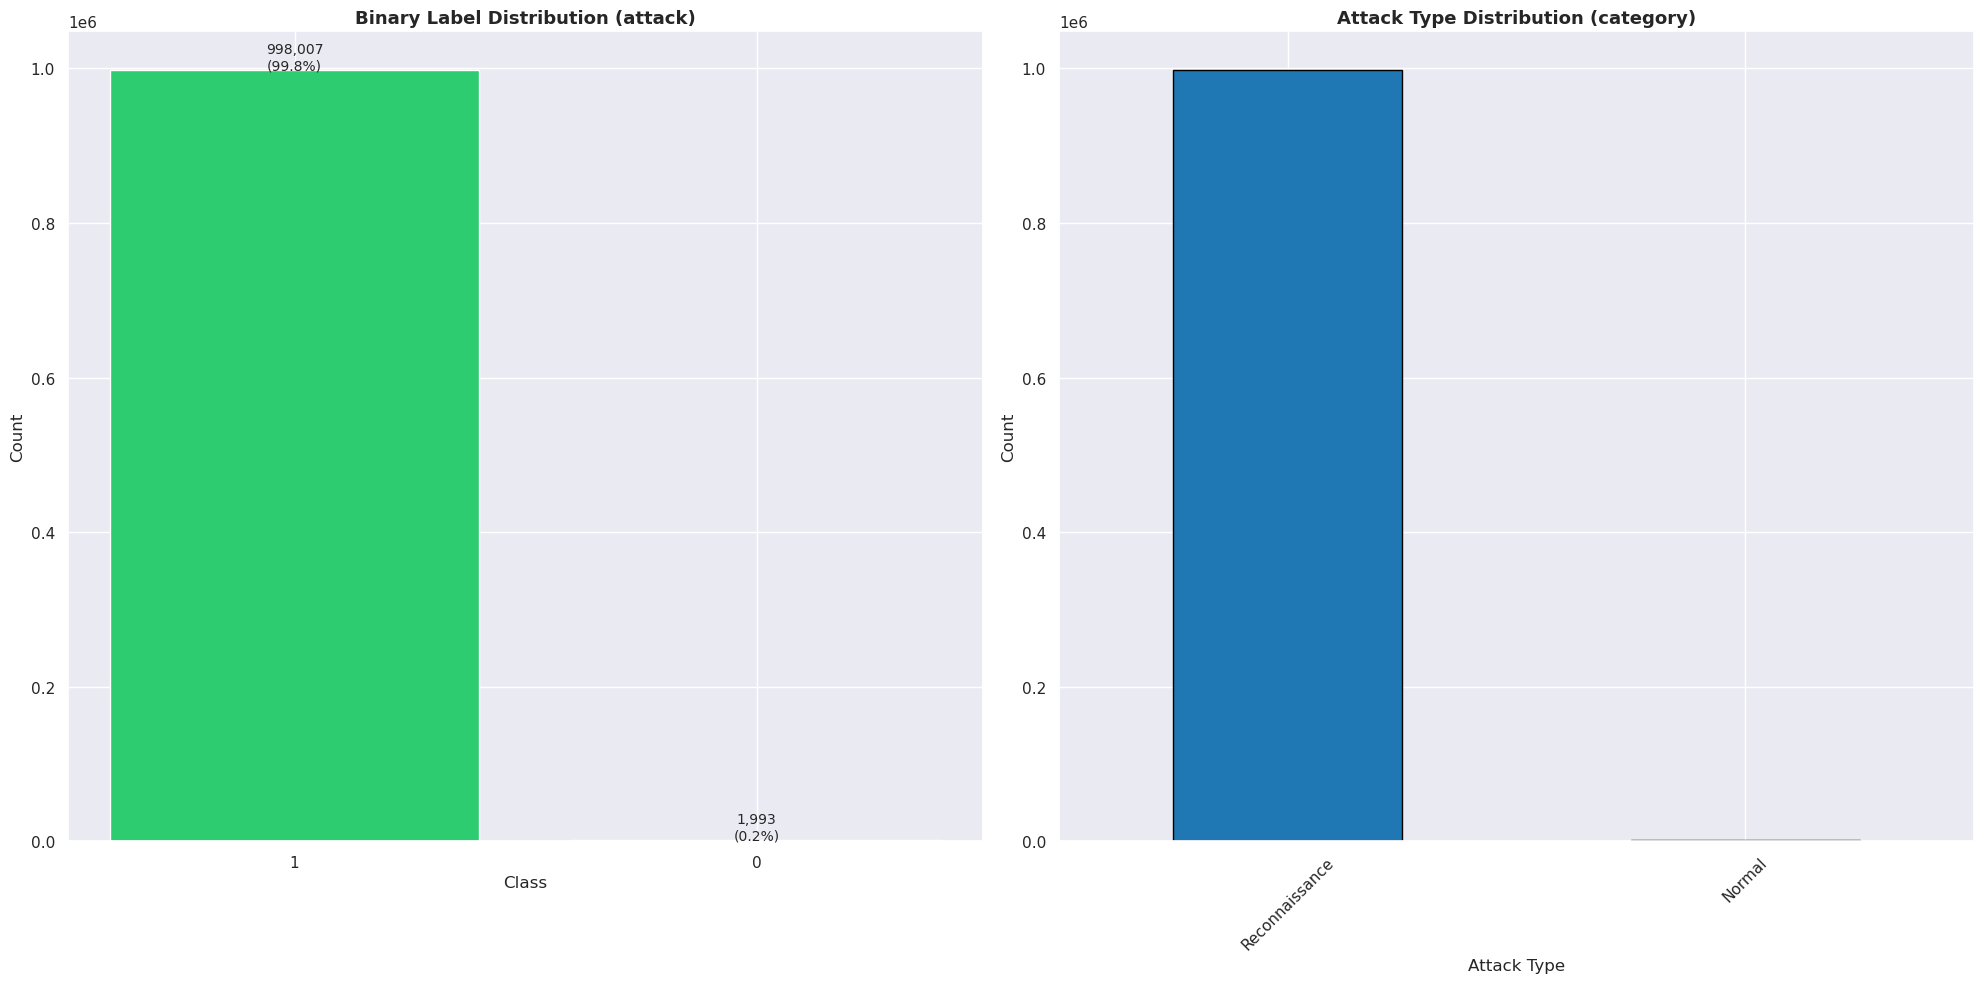


Binary:
 attack
1    998007
0      1993
Name: count, dtype: int64

Multiclass:
 category
Reconnaissance    998007
Normal              1993
Name: count, dtype: int64


In [5]:
# --- Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Binary
possible_binary = [c for c in df.columns if c.lower() in ['attack', 'label', 'labels', 'class', 'attack_label']]
possible_multi  = [c for c in df.columns if c.lower() in ['category', 'subcategory', 'type', 'attack_type']]

BINARY_TARGET = possible_binary[0] if possible_binary else 'attack'
MULTI_TARGET  = possible_multi[0] if possible_multi else 'category'

print(f'\n✅ Binary target  : {BINARY_TARGET}')
print(f'✅ Multiclass target: {MULTI_TARGET}')

binary_counts = df[BINARY_TARGET].value_counts()
axes[0].bar(binary_counts.index.astype(str), binary_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'Binary Label Distribution ({BINARY_TARGET})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Multiclass
multi_counts = df[MULTI_TARGET].value_counts()
multi_counts.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='black')
axes[1].set_title(f'Attack Type Distribution ({MULTI_TARGET})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nBinary:\n', binary_counts)
print('\nMulticlass:\n', multi_counts)

In [6]:
# --- Numeric Features Statistics ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target if numeric
for t in [BINARY_TARGET, MULTI_TARGET]:
    if t in numeric_cols:
        numeric_cols.remove(t)

print(f'Numeric features: {len(numeric_cols)}')
df[numeric_cols].describe().T.style.background_gradient(cmap='Blues')

Numeric features: 25


,count,mean,std,min,25%,50%,75%,max
pkSeqID,1000000.000000,500000.500000,288675.278932,1.000000,250000.750000,500000.500000,750000.250000,1000000.000000
stime,1000000.000000,1526825685.423988,194061.585447,1526344031.665140,1526880845.296790,1526898841.084217,1526898859.778771,1526949252.645503
pkts,1000000.000000,8.025125,494.350757,1.000000,2.000000,2.000000,2.000000,72700.000000
bytes,1000000.000000,5156.971038,478105.094978,60.000000,120.000000,120.000000,120.000000,73510808.000000
ltime,1000000.000000,1526825687.330116,194058.227709,1526344227.077939,1526880845.330144,1526898841.084615,1526898859.812287,1526949904.762483
seq,1000000.000000,98125.347005,85446.184445,1.000000,15573.000000,81392.000000,164726.000000,283299.000000
dur,1000000.000000,1.906129,41.992245,0.000000,0.000207,0.012066,0.035779,1940.859253
mean,1000000.000000,0.035261,0.203744,0.000000,0.000200,0.011737,0.035538,4.968881
stddev,1000000.000000,0.003090,0.076291,0.000000,0.000000,0.000000,0.000000,2.499505
smac,0.000000,nan,nan,nan,nan,nan,nan,nan


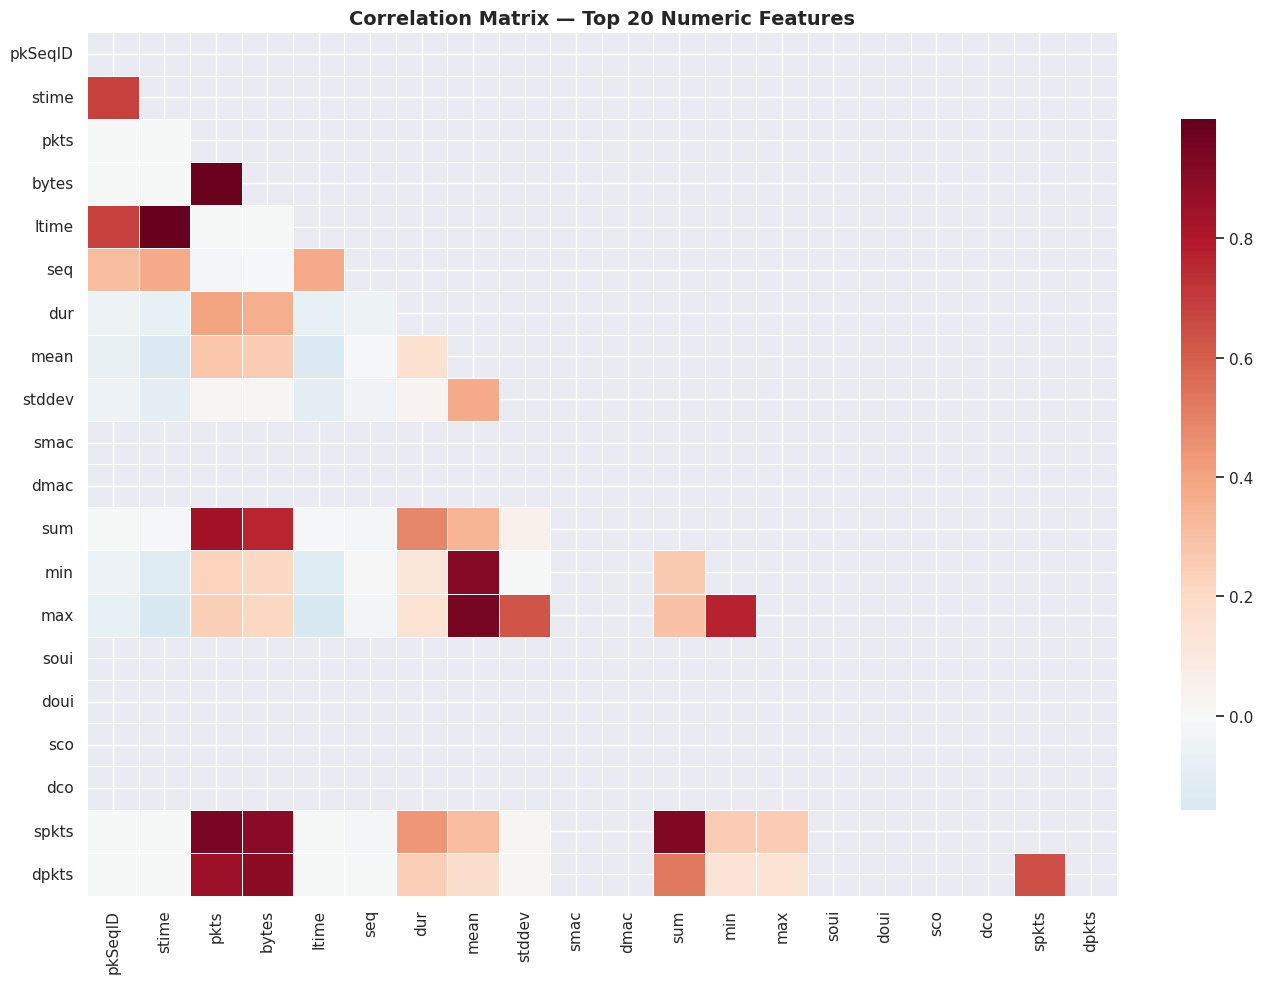

In [7]:
# --- Correlation Heatmap (top features) ---
top_n = min(20, len(numeric_cols))
corr = df[numeric_cols[:top_n]].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title(f'Correlation Matrix — Top {top_n} Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 🧹 Preprocessing

In [ ]:
# ---- 4.1  Drop constant & duplicate columns ----
df_clean = df.copy()

# Drop duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_clean):,}')

# Drop constant columns (zero variance)
const_cols = [c for c in df_clean.columns if df_clean[c].nunique() <= 1]
print(f'Constant columns dropped: {const_cols}')
df_clean.drop(columns=const_cols, inplace=True)

# Drop columns with > 90% missing
thresh = int(0.9* len(df_clean))
missing_cols = df_clean.columns[df_clean.isnull().sum() > thresh].tolist()
print(f'High-missing columns dropped: {missing_cols}')
df_clean.drop(columns=missing_cols, inplace=True)

print(f'\n✅ Shape after cleaning: {df_clean.shape}')

Duplicates removed: 0
Constant columns dropped: ['smac', 'dmac', 'soui', 'doui', 'sco', 'dco']
High-missing columns dropped: []

✅ Shape after cleaning: (1000000, 29)


In [9]:
# ---- 4.2  Handle remaining missing values ----
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target columns from feature lists
for t in [BINARY_TARGET, MULTI_TARGET]:
    if t in num_cols: num_cols.remove(t)
    if t in cat_cols: cat_cols.remove(t)

# Fill numeric with median, categorical with mode
for c in num_cols:
    df_clean[c].fillna(df_clean[c].median(), inplace=True)
for c in cat_cols:
    df_clean[c].fillna(df_clean[c].mode()[0], inplace=True)
    
df_clean['sport'] = df_clean['sport'].fillna(df_clean['sport'].median()[0])
df_clean['dport'] = df_clean['dport'].fillna(df_clean['dport'].median()[0])


print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')
print(f'Numeric features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')

Remaining nulls: 974
Numeric features : 19
Categorical features: 8


In [18]:
# ---- 4.3  Encode Targets ----
le_binary = LabelEncoder()
le_multi  = LabelEncoder()

df_clean['binary_label']    = le_binary.fit_transform(df_clean[BINARY_TARGET].astype(str))
df_clean['multiclass_label'] = le_multi.fit_transform(df_clean[MULTI_TARGET].astype(str))

print('Binary mapping  :', dict(zip(le_binary.classes_, le_binary.transform(le_binary.classes_))))
print('Multiclass mapping:', dict(zip(le_multi.classes_, le_multi.transform(le_multi.classes_))))

Binary mapping  : {'0': np.int64(0), '1': np.int64(1)}
Multiclass mapping: {'Normal': np.int64(0), 'Reconnaissance': np.int64(1)}


In [19]:
# ---- 4.4  Remove highly correlated features (> 0.98) to reduce noise ----
if len(num_cols) > 1:
    corr_matrix = df_clean[num_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [col for col in upper.columns if any(upper[col] > 0.98)]
    df_clean.drop(columns=high_corr, inplace=True)
    num_cols = [c for c in num_cols if c not in high_corr]
    print(f'High-correlation columns dropped: {len(high_corr)} → {high_corr[:5]}...')

print(f'✅ Final numeric features: {len(num_cols)}')

High-correlation columns dropped: 3 → ['bytes', 'ltime', 'dbytes']...
✅ Final numeric features: 16


## 5. 🔠 Target Encoding (Categorical Features)

In [20]:
# ---- Target Encoding for BINARY classification ----
# Target encoding replaces each category with the mean of the target variable
# Uses smoothing (m-estimate) to avoid overfitting on rare categories

FEATURE_COLS = num_cols + cat_cols  # All input features

X_raw = df_clean[FEATURE_COLS].copy()
y_binary = df_clean['binary_label'].copy()
y_multi  = df_clean['multiclass_label'].copy()

print(f'Feature matrix shape: {X_raw.shape}')
print(f'Binary target shape : {y_binary.shape}')
print(f'Multi  target shape : {y_multi.shape}')

if cat_cols:
    print(f'\nCategorical columns to encode: {cat_cols}')
    print('Sample values:')
    for c in cat_cols[:3]:
        print(f'  {c}: {X_raw[c].unique()[:5]}')
else:
    print('\n⚠️  No categorical columns found — Target Encoding will be demonstrated on binned numeric feature.')

Feature matrix shape: (1000000, 24)
Binary target shape : (1000000,)
Multi  target shape : (1000000,)

Categorical columns to encode: ['flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'state', 'subcategory ']
Sample values:
  flgs: <ArrowStringArray>
['e', 'e d', 'eU', 'e &', 'e s']
Length: 5, dtype: str
  proto: <ArrowStringArray>
['arp', 'tcp', 'udp', 'icmp', 'ipv6-icmp']
Length: 5, dtype: str
  saddr: <ArrowStringArray>
[  '192.168.100.1',   '192.168.100.7', '192.168.100.149',   '192.168.100.4',
  '192.168.100.27']
Length: 5, dtype: str


In [21]:
# --- Apply Target Encoding ---
# If no categorical columns exist, create a demo one from a numeric feature
X_encoded_binary = X_raw.copy()
X_encoded_multi  = X_raw.copy()

demo_col_added = False
if not cat_cols:
    # Create a binned feature for demonstration
    demo_col = 'proto_bin'
    base_col = num_cols[0] if num_cols else None
    if base_col:
        X_encoded_binary[demo_col] = pd.qcut(X_encoded_binary[base_col], q=5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop').astype(str)
        X_encoded_multi[demo_col]  = X_encoded_binary[demo_col].copy()
        cat_cols_to_encode = [demo_col]
        demo_col_added = True
        print(f'⚠️  Created demo categorical column "{demo_col}" for Target Encoding demonstration')
    else:
        cat_cols_to_encode = []
else:
    cat_cols_to_encode = cat_cols

if cat_cols_to_encode:
    # Binary target encoding
    te_binary = ce.TargetEncoder(cols=cat_cols_to_encode, smoothing=1.0)
    X_encoded_binary[cat_cols_to_encode] = te_binary.fit_transform(X_encoded_binary[cat_cols_to_encode], y_binary)

    # Multiclass target encoding (encode against mean of each class's encoded target)
    te_multi = ce.TargetEncoder(cols=cat_cols_to_encode, smoothing=1.0)
    X_encoded_multi[cat_cols_to_encode] = te_multi.fit_transform(X_encoded_multi[cat_cols_to_encode], y_multi)

    print(f'\n✅ Target Encoding applied to: {cat_cols_to_encode}')
    print(f'\nSample encoded values (binary):')
    print(X_encoded_binary[cat_cols_to_encode].head())
else:
    te_binary = None
    te_multi  = None
    print('No categorical columns to encode.')


✅ Target Encoding applied to: ['flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'state', 'subcategory ']

Sample encoded values (binary):
    flgs  proto  saddr  sport  daddr  dport  state  subcategory 
0 0.9980 0.5216 0.0000 0.5216 0.9999 0.5216 0.5398        0.0000
1 0.9980 0.9998 0.9181 0.9980 0.0067 0.9980 0.5398        0.0000
2 0.9980 0.9636 0.9993 0.9980 0.9801 0.5417 0.5398        0.0000
3 0.9980 0.5216 0.0000 0.5216 0.9997 0.5216 0.5398        0.0000
4 0.9980 0.9636 0.0000 0.9812 0.0000 0.1684 0.5398        0.0000


## 6. ⚖️ Min-Max Scaling

✅ Min-Max Scaling applied!

Binary features — Min: 0.0000, Max: 1.0000
Multi  features — Min: 0.0000, Max: 1.0000


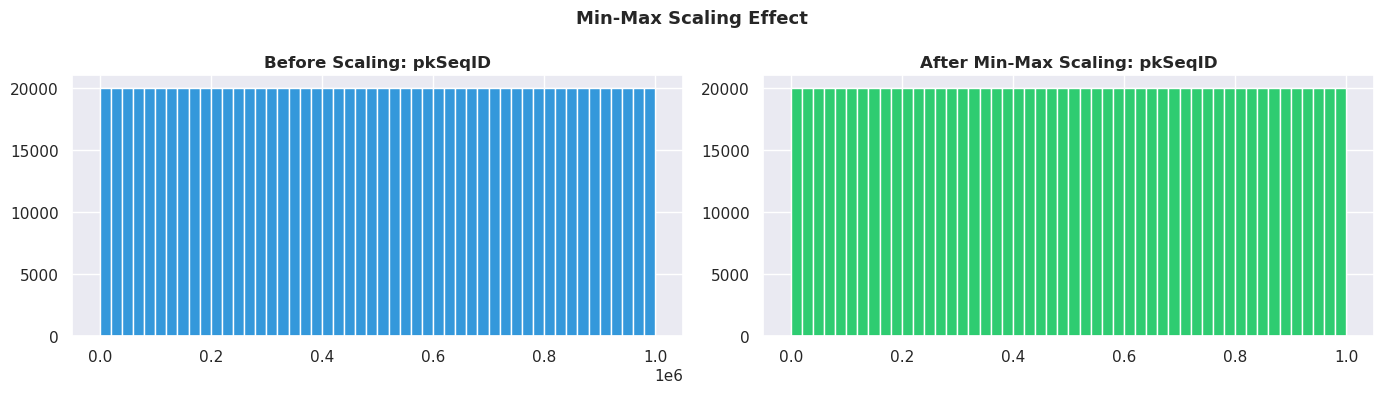

In [22]:
# Min-Max Scaling normalizes all features to [0, 1] range
# Formula: x' = (x - x_min) / (x_max - x_min)
# Required for Naive Bayes (GaussianNB) to perform well

scaler_binary = MinMaxScaler(feature_range=(0, 1))
scaler_multi  = MinMaxScaler(feature_range=(0, 1))

X_scaled_binary = pd.DataFrame(
    scaler_binary.fit_transform(X_encoded_binary),
    columns=X_encoded_binary.columns
)

X_scaled_multi = pd.DataFrame(
    scaler_multi.fit_transform(X_encoded_multi),
    columns=X_encoded_multi.columns
)

print('✅ Min-Max Scaling applied!')
print(f'\nBinary features — Min: {X_scaled_binary.min().min():.4f}, Max: {X_scaled_binary.max().max():.4f}')
print(f'Multi  features — Min: {X_scaled_multi.min().min():.4f}, Max: {X_scaled_multi.max().max():.4f}')

# Visual comparison before/after scaling
if num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sample_col = num_cols[0]
    axes[0].hist(X_raw[sample_col].dropna(), bins=50, color='#3498db', edgecolor='white')
    axes[0].set_title(f'Before Scaling: {sample_col}', fontweight='bold')
    axes[1].hist(X_scaled_binary[sample_col], bins=50, color='#2ecc71', edgecolor='white')
    axes[1].set_title(f'After Min-Max Scaling: {sample_col}', fontweight='bold')
    plt.suptitle('Min-Max Scaling Effect', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('scaling_effect.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. ✂️ Train/Test Split

In [23]:
TEST_SIZE   = 0.2
RANDOM_STATE = 42

# Binary split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled_binary, y_binary,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_binary
)

# Multiclass split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled_multi, y_multi,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_multi
)

print('📊 Train/Test Split Summary')
print(f'  Binary   — Train: {X_train_b.shape[0]:>7,} | Test: {X_test_b.shape[0]:>6,}')
print(f'  Multiclass — Train: {X_train_m.shape[0]:>7,} | Test: {X_test_m.shape[0]:>6,}')

📊 Train/Test Split Summary
  Binary   — Train: 800,000 | Test: 200,000
  Multiclass — Train: 800,000 | Test: 200,000


In [24]:
# ---- SMOTE Oversampling for imbalanced multiclass ----
# Only apply if imbalance ratio > 5:1
class_counts = y_train_m.value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Multiclass imbalance ratio: {imbalance_ratio:.1f}:1')

if imbalance_ratio > 5:
    print('⚠️  Applying SMOTE to balance multiclass training set...')
    # Only apply SMOTE where class has at least 2 samples
    min_samples = class_counts[class_counts >= 2].index
    mask_m = y_train_m.isin(min_samples)
    
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, class_counts.min()-1))
    X_train_m_res, y_train_m_res = smote.fit_resample(X_train_m[mask_m], y_train_m[mask_m])
    print(f'  After SMOTE — Train: {X_train_m_res.shape[0]:,}')
else:
    X_train_m_res, y_train_m_res = X_train_m, y_train_m
    print('✅ Dataset is balanced enough — no SMOTE needed.')

Multiclass imbalance ratio: 500.9:1
⚠️  Applying SMOTE to balance multiclass training set...
  After SMOTE — Train: 1,596,812


## 8. 🤖 Model Training — Naive Bayes

In [25]:
# ========================================================
# MODEL 1: BINARY CLASSIFICATION (Normal vs Attack)
# ========================================================
print('=' * 55)
print('  MODEL 1 — BINARY: Normal vs Attack (GaussianNB)')
print('=' * 55)

gnb_binary = GaussianNB(var_smoothing=1e-9)
gnb_binary.fit(X_train_b, y_train_b)

y_pred_b = gnb_binary.predict(X_test_b)
y_prob_b = gnb_binary.predict_proba(X_test_b)[:, 1]

acc_b = accuracy_score(y_test_b, y_pred_b)
f1_b  = f1_score(y_test_b, y_pred_b, average='weighted')
prec_b = precision_score(y_test_b, y_pred_b, average='weighted')
rec_b  = recall_score(y_test_b, y_pred_b, average='weighted')

try:
    auc_b = roc_auc_score(y_test_b, y_prob_b)
except:
    auc_b = float('nan')

print(f'\n  Accuracy  : {acc_b:.4f} ({acc_b*100:.2f}%)')
print(f'  Precision : {prec_b:.4f}')
print(f'  Recall    : {rec_b:.4f}')
print(f'  F1-Score  : {f1_b:.4f}')
print(f'  AUC-ROC   : {auc_b:.4f}')

print('\n  Classification Report:')
target_names_b = [f'Class {c}' for c in le_binary.classes_]
print(classification_report(y_test_b, y_pred_b, target_names=target_names_b))

  MODEL 1 — BINARY: Normal vs Attack (GaussianNB)

  Accuracy  : 1.0000 (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  AUC-ROC   : 1.0000

  Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       399
     Class 1       1.00      1.00      1.00    199601

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [26]:
# ========================================================
# MODEL 2: MULTICLASS CLASSIFICATION (Attack Type)
# ComplementNB is better for imbalanced multiclass
# ========================================================
print('=' * 55)
print('  MODEL 2 — MULTICLASS: Attack Type (ComplementNB)')
print('=' * 55)

# ComplementNB works with non-negative data (guaranteed by MinMaxScaler [0,1])
cnb_multi = ComplementNB(alpha=1.0)  
cnb_multi.fit(X_train_m_res, y_train_m_res)

y_pred_m = cnb_multi.predict(X_test_m)
y_prob_m = cnb_multi.predict_proba(X_test_m)

acc_m  = accuracy_score(y_test_m, y_pred_m)
f1_m   = f1_score(y_test_m, y_pred_m, average='weighted')
prec_m = precision_score(y_test_m, y_pred_m, average='weighted', zero_division=0)
rec_m  = recall_score(y_test_m, y_pred_m, average='weighted')

try:
    auc_m = roc_auc_score(y_test_m, y_prob_m, multi_class='ovr', average='weighted')
except:
    auc_m = float('nan')

print(f'\n  Accuracy  : {acc_m:.4f} ({acc_m*100:.2f}%)')
print(f'  Precision : {prec_m:.4f}')
print(f'  Recall    : {rec_m:.4f}')
print(f'  F1-Score  : {f1_m:.4f}')
print(f'  AUC-ROC   : {auc_m:.4f}')

target_names_m = [str(c) for c in le_multi.classes_]
print('\n  Classification Report:')
print(classification_report(y_test_m, y_pred_m, target_names=target_names_m, zero_division=0))

  MODEL 2 — MULTICLASS: Attack Type (ComplementNB)

  Accuracy  : 0.9998 (99.98%)
  Precision : 0.9998
  Recall    : 0.9998
  F1-Score  : 0.9998
  AUC-ROC   : nan

  Classification Report:
                precision    recall  f1-score   support

        Normal       1.00      0.88      0.94       399
Reconnaissance       1.00      1.00      1.00    199601

      accuracy                           1.00    200000
     macro avg       1.00      0.94      0.97    200000
  weighted avg       1.00      1.00      1.00    200000



## 9. 📊 Evaluation & Visualizations

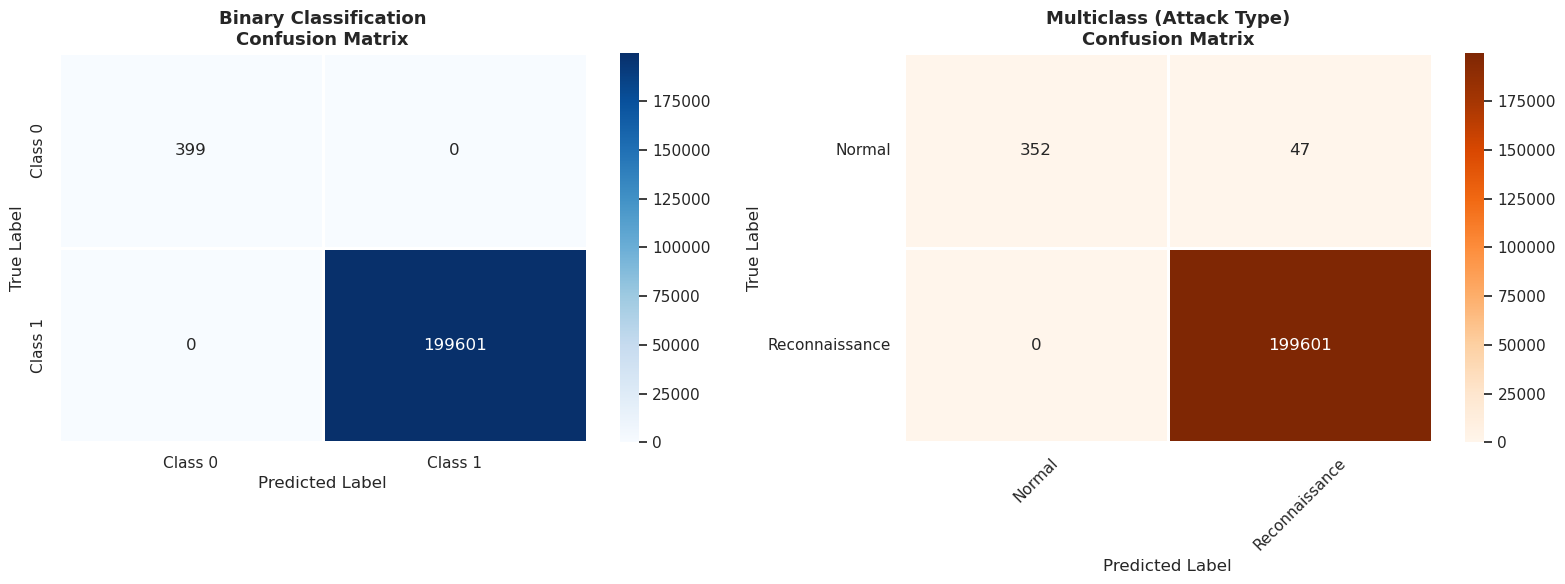

In [27]:
# ---- Confusion Matrices ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary CM
cm_b = confusion_matrix(y_test_b, y_pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names_b, yticklabels=target_names_b,
            linewidths=1, linecolor='white')
axes[0].set_title('Binary Classification\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Multiclass CM
cm_m = confusion_matrix(y_test_m, y_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=target_names_m, yticklabels=target_names_m,
            linewidths=1, linecolor='white')
axes[1].set_title('Multiclass (Attack Type)\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

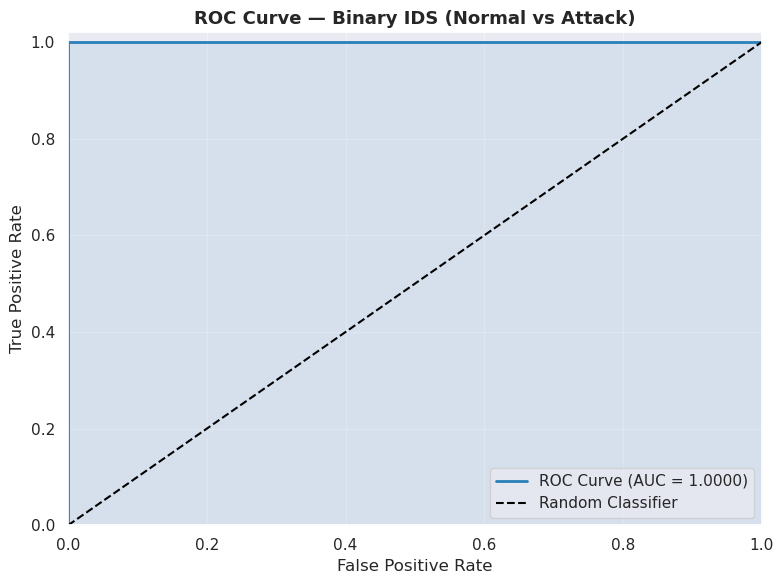

In [28]:
# ---- ROC Curve (Binary) ----
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_b, y_prob_b)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Binary IDS (Normal vs Attack)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curve_binary.png', dpi=150, bbox_inches='tight')
plt.show()

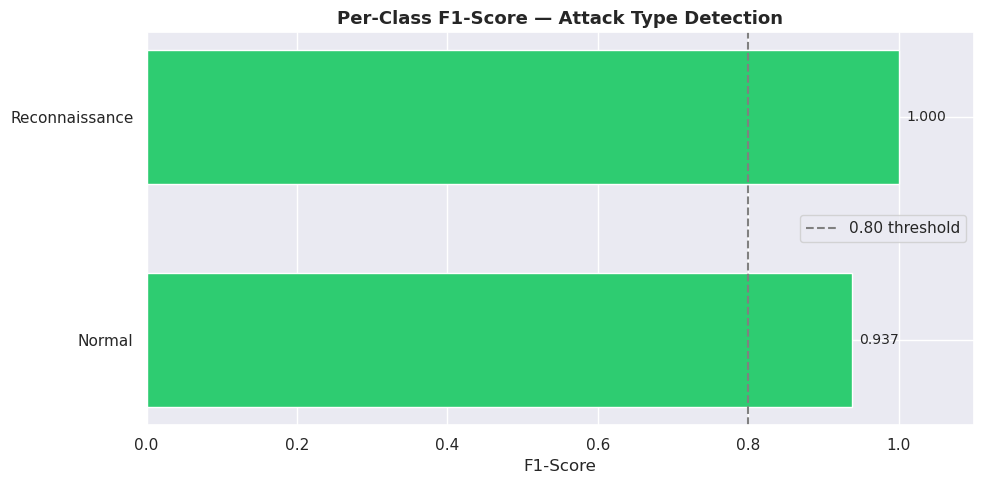

In [29]:
# ---- Per-Class F1-Score (Multiclass) ----
from sklearn.metrics import f1_score as f1

f1_per_class = f1(y_test_m, y_pred_m, average=None, zero_division=0)
class_labels = [str(c) for c in le_multi.classes_]

# Only show classes that appear in test set
unique_test = np.unique(y_test_m)
f1_df = pd.DataFrame({'Class': [class_labels[i] for i in unique_test],
                       'F1-Score': f1_per_class[unique_test]})
f1_df = f1_df.sort_values('F1-Score', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.8 else '#2ecc71' for v in f1_df['F1-Score']]
bars = plt.barh(f1_df['Class'], f1_df['F1-Score'], color=colors, edgecolor='white', height=0.6)
plt.axvline(x=0.8, color='gray', linestyle='--', lw=1.5, label='0.80 threshold')
for bar, val in zip(bars, f1_df['F1-Score']):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
plt.xlabel('F1-Score', fontsize=12)
plt.title('Per-Class F1-Score — Attack Type Detection', fontsize=13, fontweight='bold')
plt.xlim([0, 1.1])
plt.legend()
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ---- Metrics Dashboard Summary ----
metrics = {
    'Model': ['Binary (GaussianNB)', 'Multiclass (ComplementNB)'],
    'Task': ['Normal vs Attack', 'Attack Type Detection'],
    'Accuracy': [acc_b, acc_m],
    'Precision': [prec_b, prec_m],
    'Recall': [rec_b, rec_m],
    'F1-Score': [f1_b, f1_m],
    'AUC-ROC': [auc_b, auc_m]
}
metrics_df = pd.DataFrame(metrics)
print('\n' + '='*65)
print('           📊 FINAL METRICS SUMMARY — IDS')
print('='*65)
print(metrics_df.to_string(index=False))
print('='*65)
metrics_df.set_index('Model').style.background_gradient(cmap='YlGn', subset=['Accuracy','F1-Score','AUC-ROC'])


           📊 FINAL METRICS SUMMARY — IDS
                    Model                  Task  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      Binary (GaussianNB)      Normal vs Attack    1.0000     1.0000  1.0000    1.0000   1.0000
Multiclass (ComplementNB) Attack Type Detection    0.9998     0.9998  0.9998    0.9998      NaN


,Task,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,,
Binary (GaussianNB),Normal vs Attack,1.000000,1.000000,1.000000,1.000000,1.000000
Multiclass (ComplementNB),Attack Type Detection,0.999765,0.999765,0.999765,0.999758,nan


## 10. 🔁 Cross-Validation

Running 5-Fold CV...

[Binary — GaussianNB]  CV F1: 1.0000 ± 0.0000
  Per-fold: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]

[Multiclass — ComplementNB]  CV F1: 0.9987 ± 0.0000
  Per-fold: [np.float64(0.9988), np.float64(0.9987), np.float64(0.9987), np.float64(0.9987), np.float64(0.9987)]


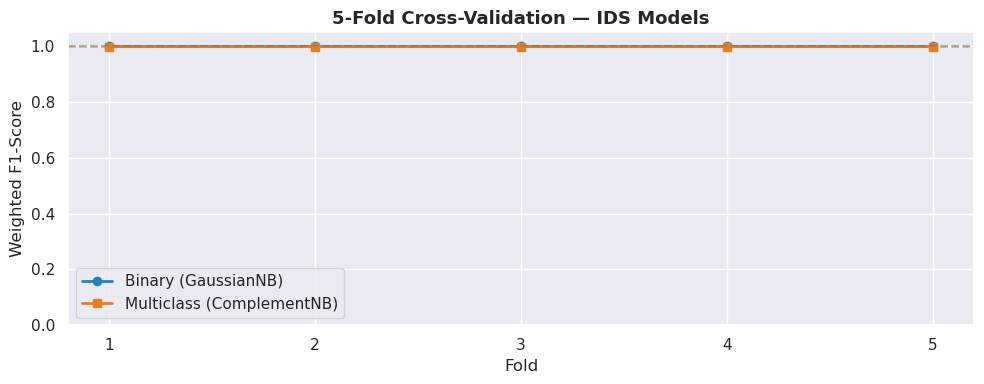

In [31]:
# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running 5-Fold CV...')

# Binary
cv_scores_b = cross_val_score(GaussianNB(), X_scaled_binary, y_binary, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f'\n[Binary — GaussianNB]  CV F1: {cv_scores_b.mean():.4f} ± {cv_scores_b.std():.4f}')
print(f'  Per-fold: {[round(s,4) for s in cv_scores_b]}')

# Multiclass
cv_scores_m = cross_val_score(ComplementNB(), X_scaled_multi, y_multi, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f'\n[Multiclass — ComplementNB]  CV F1: {cv_scores_m.mean():.4f} ± {cv_scores_m.std():.4f}')
print(f'  Per-fold: {[round(s,4) for s in cv_scores_m]}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(1, 6)
ax.plot(x, cv_scores_b, 'o-', color='#2980b9', label='Binary (GaussianNB)', lw=2)
ax.plot(x, cv_scores_m, 's-', color='#e67e22', label='Multiclass (ComplementNB)', lw=2)
ax.axhline(y=cv_scores_b.mean(), color='#2980b9', linestyle='--', alpha=0.5)
ax.axhline(y=cv_scores_m.mean(), color='#e67e22', linestyle='--', alpha=0.5)
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation — IDS Models', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 🔮 Real-Time Prediction Function

In [32]:
def predict_intrusion(raw_sample_df: pd.DataFrame) -> pd.DataFrame:
    """
    IDS Prediction Pipeline
    -----------------------
    Input : raw DataFrame row(s) with the same columns as training data
    Output: DataFrame with columns:
            - 'attack_detected'  (0=Normal, 1=Attack)
            - 'attack_type'      (attack category name)
            - 'attack_prob'      (probability of attack)
            - 'confidence'       (max class probability)
    """
    sample = raw_sample_df[FEATURE_COLS].copy()

    # Step 1: Fill missing
    for c in num_cols:
        if c in sample.columns:
            sample[c] = sample[c].fillna(df_clean[c].median())
    for c in cat_cols_to_encode if cat_cols_to_encode else []:
        if c in sample.columns:
            sample[c] = sample[c].fillna(sample[c].mode()[0] if len(sample[c]) > 0 else 'Unknown')

    # Step 2: Target Encoding
    if te_binary and cat_cols_to_encode:
        sample_b = sample.copy()
        sample_m = sample.copy()
        sample_b[cat_cols_to_encode] = te_binary.transform(sample_b[cat_cols_to_encode])
        sample_m[cat_cols_to_encode] = te_multi.transform(sample_m[cat_cols_to_encode])
    else:
        sample_b = sample.copy()
        sample_m = sample.copy()

    # Step 3: Min-Max Scaling
    sample_scaled_b = scaler_binary.transform(sample_b)
    sample_scaled_m = scaler_multi.transform(sample_m)

    # Step 4: Predict
    binary_pred  = gnb_binary.predict(sample_scaled_b)
    binary_prob  = gnb_binary.predict_proba(sample_scaled_b)[:, 1]
    multi_pred   = cnb_multi.predict(sample_scaled_m)
    multi_prob   = cnb_multi.predict_proba(sample_scaled_m)

    results = pd.DataFrame({
        'attack_detected': binary_pred,
        'attack_type'    : le_multi.inverse_transform(multi_pred),
        'attack_prob'    : binary_prob.round(4),
        'confidence'     : multi_prob.max(axis=1).round(4)
    })
    return results

# Demo: predict on 5 random test samples
demo_indices = np.random.choice(len(X_test_b), size=5, replace=False)
demo_raw = df_clean[FEATURE_COLS].iloc[demo_indices]

preds = predict_intrusion(demo_raw)
preds['true_binary'] = y_binary.iloc[demo_indices].values
preds['true_type']   = le_multi.inverse_transform(y_multi.iloc[demo_indices].values)
print('\n🔮 Sample Predictions:')
print(preds.to_string(index=False))


🔮 Sample Predictions:
 attack_detected    attack_type  attack_prob  confidence  true_binary      true_type
               1 Reconnaissance       1.0000      1.0000            1 Reconnaissance
               1 Reconnaissance       1.0000      1.0000            1 Reconnaissance
               1 Reconnaissance       1.0000      1.0000            1 Reconnaissance
               1 Reconnaissance       1.0000      1.0000            1 Reconnaissance
               1 Reconnaissance       1.0000      1.0000            1 Reconnaissance


## 12. 💾 Save Models & Results

In [33]:
import joblib, json, os

os.makedirs('ids_models', exist_ok=True)

# Save models
joblib.dump(gnb_binary,    'ids_models/gnb_binary.pkl')
joblib.dump(cnb_multi,     'ids_models/cnb_multi.pkl')
joblib.dump(scaler_binary, 'ids_models/scaler_binary.pkl')
joblib.dump(scaler_multi,  'ids_models/scaler_multi.pkl')
joblib.dump(le_binary,     'ids_models/le_binary.pkl')
joblib.dump(le_multi,      'ids_models/le_multi.pkl')
if te_binary:
    joblib.dump(te_binary, 'ids_models/te_binary.pkl')
    joblib.dump(te_multi,  'ids_models/te_multi.pkl')

# Save metrics
results = {
    'binary_model':     'GaussianNB',
    'multiclass_model': 'ComplementNB',
    'encoding':         'Target Encoding',
    'scaling':          'Min-Max Scaling',
    'binary_metrics': {
        'accuracy': round(acc_b,  4),
        'precision': round(prec_b, 4),
        'recall':   round(rec_b,  4),
        'f1_score': round(f1_b,   4),
        'auc_roc':  round(float(auc_b), 4) if not np.isnan(auc_b) else None,
        'cv_f1_mean': round(cv_scores_b.mean(), 4),
        'cv_f1_std':  round(cv_scores_b.std(),  4)
    },
    'multiclass_metrics': {
        'accuracy': round(acc_m,  4),
        'precision': round(prec_m, 4),
        'recall':   round(rec_m,  4),
        'f1_score': round(f1_m,   4),
        'auc_roc':  round(float(auc_m), 4) if not np.isnan(auc_m) else None,
        'cv_f1_mean': round(cv_scores_m.mean(), 4),
        'cv_f1_std':  round(cv_scores_m.std(),  4)
    },
    'attack_classes': list(le_multi.classes_)
}

with open('ids_models/metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print('✅ Models and metrics saved to ids_models/')
print(json.dumps(results, indent=2))

✅ Models and metrics saved to ids_models/
{
  "binary_model": "GaussianNB",
  "multiclass_model": "ComplementNB",
  "encoding": "Target Encoding",
  "scaling": "Min-Max Scaling",
  "binary_metrics": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1_score": 1.0,
    "auc_roc": 1.0,
    "cv_f1_mean": 1.0,
    "cv_f1_std": 0.0
  },
  "multiclass_metrics": {
    "accuracy": 0.9998,
    "precision": 0.9998,
    "recall": 0.9998,
    "f1_score": 0.9998,
    "auc_roc": null,
    "cv_f1_mean": 0.9987,
    "cv_f1_std": 0.0
  },
  "attack_classes": [
    "Normal",
    "Reconnaissance"
  ]
}


## 13. 📝 Final Report

In [34]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           🛡️  IDS — FINAL REPORT SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset : BoT-IoT                                               ║
║  Encoding: Target Encoding (category → mean target value)        ║
║  Scaling : Min-Max Normalization [0, 1]                          ║
╠══════════════════════════════════════════════════════════════════╣
║  TASK 1: Binary Classification (Normal vs Attack)                ║
║    Model     : Gaussian Naive Bayes                              ║
╠══════════════════════════════════════════════════════════════════╣
║  TASK 2: Multiclass Classification (Attack Type)                 ║
║    Model     : Complement Naive Bayes                            ║
║    (better for imbalanced + multiclass than GaussianNB)          ║
╠══════════════════════════════════════════════════════════════════╣
║  Output Files:                                                   ║
║    ids_models/gnb_binary.pkl    — Binary IDS model               ║
║    ids_models/cnb_multi.pkl     — Multiclass Attack Type model   ║
║    ids_models/scaler_*.pkl      — Fitted MinMaxScalers           ║
║    ids_models/le_*.pkl          — Label Encoders                 ║
║    ids_models/metrics.json      — All evaluation metrics         ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           🛡️  IDS — FINAL REPORT SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset : BoT-IoT                                               ║
║  Encoding: Target Encoding (category → mean target value)        ║
║  Scaling : Min-Max Normalization [0, 1]                          ║
╠══════════════════════════════════════════════════════════════════╣
║  TASK 1: Binary Classification (Normal vs Attack)                ║
║    Model     : Gaussian Naive Bayes                              ║
╠══════════════════════════════════════════════════════════════════╣
║  TASK 2: Multiclass Classification (Attack Type)                 ║
║    Model     : Complement Naive Bayes                            ║
║    (better for imbalanced + multiclass than GaussianNB)          ║
╠══════════════════════════════════════════════════════════════════╣
║  Output Files:                  